# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `lab1/data/master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Гнатюк Ярослав Богданович'
ГРУПА = 'ШІ-31'
ВАРІАНТ = 4

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Гнатюк Ярослав Богданович, ШІ-31, варіант 4
ваш потік:                   P>100
ваша пара для графіка 3:     радіопотік F10.7 та швидкість вітру
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
df = pd.read_excel('lab1/data/20171129_FINAL_FINAL.xlsx')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7225 entries, 0 to 7224
Data columns (total 32 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   0 non-null      float64
 1   ftp://ftp.swpc.noaa.gov/pub/lists/particle/  7222 non-null   object 
 2   Unnamed: 2                                   7202 non-null   object 
 3   Unnamed: 3                                   7202 non-null   object 
 4   Unnamed: 4                                   7202 non-null   object 
 5   Unnamed: 5                                   7203 non-null   object 
 6   Unnamed: 6                                   7203 non-null   object 
 7   Unnamed: 7                                   7198 non-null   object 
 8   Unnamed: 8                                   7198 non-null   object 
 9   Unnamed: 9                                   7198 non-null   object 
 10  

In [6]:
df.head(5)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

Використана нами функція очікує, що поданий файл буде містити у собі одну чисту таблицю з даними, проте, схоже, файл містить багато зайвого тексту і тп, що суперечить очікуванням

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [7]:
# ВАШ КОД
RAW = pd.read_excel('lab1/data/20171129_FINAL_FINAL.xlsx', header=None)

In [8]:
RAW.shape

(7226, 32)

In [9]:
RAW.head(30)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [10]:
# ВАШ КОД
RAW.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

Виглядає так, що таблиць три: [1:15], [16:20] та [24:32] (якщо вказувати як в пайтон слайсингу)

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [11]:
# ВАШ КОД
notes_area = {'A': (slice(0, 26), slice(1, 15)),
              'B': (slice(0, 27), slice(16, 20)),
              'C': (slice(0, 27), slice(24, 32))}

for name, (rows, cols) in notes_area.items():
    print('=== Таблиця', name, '===')
    for i, row in RAW.iloc[rows, cols].iterrows():
        text = '  '.join(str(v) for v in row.dropna())
        if text:
            print('рядок %2d: %s' % (i, text))
    print()

=== Таблиця A ===
рядок  0: ftp://ftp.swpc.noaa.gov/pub/lists/particle/
рядок  2: :Data_list: 20170901_Gs_part_5m.txt
рядок  3: :Created: 2017 Sep 02 0011 UTC
рядок  4: # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
рядок  5: # Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
рядок  6: # 
рядок  7: # Label: P > 1 = Particles at >1 Mev
рядок  8: # Label: P > 5 = Particles at >5 Mev
рядок  9: # Label: P >10 = Particles at >10 Mev
рядок 10: # Label: P >30 = Particles at >30 Mev
рядок 11: # Label: P >50 = Particles at >50 Mev
рядок 12: # Label: P>100 = Particles at >100 Mev
рядок 13: # Label: E>0.8 = Electrons at >0.8 Mev
рядок 14: # Label: E>2.0 = Electrons at >2.0 Mev
рядок 15: # Label: E>4.0 = Electrons at >4.0 Mev
рядок 16: # Units: Particles = Protons/cm2-s-sr
рядок 17: # Units: Electrons = Electrons/cm2-s-sr
рядок 18: # Source: GOES-15
рядок 19: # Location: W135
рядок 20: # Missing data: -1.00e+05
рядок 22: 5-minute  GOES-15 Solar Part

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання                          |
|---|---|----------------------------------------------|
| A | GOES-15 Solar | P = Protons/cm2-s-sr, E = Electrons/cm2-s-sr |
| B | NOAA SWPC, Daily Solar Data | -                                            |
| C | SOHO CELIAS Proton Monitor | Proton speed [km/sec], Proton density [protons per cubic centimeter]                      |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [12]:
RAW.iloc[25:55]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
25,NaN,# YR,MO,DA,HHMM,Day,Day,P > 1,P > 5,P >10,P >30,P >50,P>100,E>0.8,E>2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,NaN,2017,8,28,0,57993,0,12,0.26,0.18,0.114,0.104,0.0793,23600,1180,NaN,NaN,Month,Date,Radio Flux 10.7,NaN,NaN,NaN,NaN,NaN,NaN,# YR,MO,DA,HH,SPEED,DENSITY
27,NaN,2017,8,28,5,57993,300,19.4,0.69,0.314,0.112,0.0612,0.0251,23100,1160,NaN,2017,8,28,82,NaN,NaN,NaN,NaN,0.0,0.0,17,8,28,0,285,3
28,NaN,2017,8,28,10,57993,600,8.48,0.168,0.13,0.0717,0.0614,0.0304,22200,1090,NaN,2017,8,29,84,NaN,NaN,NaN,NaN,1.0,1.0,17,8,28,1,305,3.4
29,NaN,2017,8,28,15,57993,900,15.4,0.566,0.198,0.0926,0.0568,0.0251,20400,997,NaN,2017,8,30,87,NaN,NaN,NaN,NaN,2.0,2.0,17,8,28,2,309,1.7
30,NaN,2017,8,28,20,57993,1200,6.41,0.156,0.118,0.0597,0.0494,0.0251,18500,875,NaN,2017,8,31,92,NaN,NaN,NaN,NaN,3.0,3.0,17,8,28,3,304,2
31,NaN,2017,8,28,25,57993,1500,9.94,0.495,0.31,0.224,0.178,0.063,19600,950,NaN,2017,9,1,93,NaN,NaN,NaN,NaN,4.0,4.0,17,8,28,4,302,2.3
32,NaN,2017,8,28,30,57993,1800,6.47,0.344,0.306,0.065,0.0547,0.0268,19800,952,NaN,2017,9,2,100,NaN,NaN,NaN,NaN,5.0,5.0,17,8,28,5,304,2.4
33,NaN,2017,8,28,35,57993,2100,11,0.334,0.121,0.0597,0.0494,0.0251,20100,966,NaN,2017,9,3,120,NaN,NaN,NaN,NaN,6.0,6.0,17,8,28,6,319,3.2
34,NaN,2017,8,28,40,57993,2400,6.36,0.21,0.171,0.113,0.103,0.0572,20600,993,NaN,2017,9,4,140,NaN,NaN,NaN,NaN,7.0,7.0,17,8,28,7,319,2.8


In [13]:
# ВАШ КОД
A = RAW.iloc[26:, 1:15].dropna(how='all').copy()
A.columns = ['YR', 'MO', 'DA', 'HHMM', 'MJD', 'SEC'] + ПОТОКИ

B = RAW.iloc[27:, 16:20].dropna(how='all').copy()
B.columns = ['YR', 'MO', 'DA', 'F10.7']

C = RAW.iloc[27:, 26:32].dropna(how='all').copy()
C.columns = ['YR', 'MO', 'DA', 'HH', 'speed', 'density']

A, B, C = [t.apply(pd.to_numeric, errors='coerce').reset_index(drop=True) for t in (A, B, C)]

print('рядків у A, B, C:', len(A), len(B), len(C))

рядків у A, B, C: 7200 25 601


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [14]:
A.columns

Index(['YR', 'MO', 'DA', 'HHMM', 'MJD', 'SEC', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0'], dtype='object')

In [15]:
B.columns

Index(['YR', 'MO', 'DA', 'F10.7'], dtype='object')

In [16]:
C.columns

Index(['YR', 'MO', 'DA', 'HH', 'speed', 'density'], dtype='object')

In [17]:
# ВАШ КОД
A['ts'] = pd.to_datetime({'year': A['YR'], 'month': A['MO'], 'day': A['DA'],
                          'hour': A['HHMM'] // 100, 'minute': A['HHMM'] % 100})

B['ts'] = pd.to_datetime({'year': B['YR'], 'month': B['MO'], 'day': B['DA']})

C['ts'] = pd.to_datetime({'year': 2000 + C['YR'], 'month': C['MO'], 'day': C['DA'], 'hour': C['HH']})

for name, t in [('A', A), ('B', B), ('C', C)]:
    print('%s: від %s до %s' % (name, t['ts'].min(), t['ts'].max()))

A: від 2017-08-28 00:00:00 до 2017-09-21 23:55:00
B: від 2017-08-28 00:00:00 до 2017-09-21 00:00:00
C: від 2017-08-28 00:00:00 до 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [18]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [19]:
# ВАШ КОД
for name, t in [('A', A), ('B', B), ('C', C)]:
    print('=' * 78)
    print('ТАБЛИЦЯ', name)
    print('=' * 78)
    print('розмір:', t.shape)
    print('\nтипи стовпців:')
    print(t.dtypes.to_string())
    print('\nпропуски в кожному стовпці:')
    print(t.isna().sum().to_string())
    print('\nповних дублікатів рядків:', t.duplicated().sum())
    print('\nописові статистики:')
    display(t.select_dtypes('number').describe())

ТАБЛИЦЯ A
розмір: (7200, 15)

типи стовпців:
YR                int64
MO                int64
DA                int64
HHMM              int64
MJD               int64
SEC               int64
P>1             float64
P>5             float64
P>10            float64
P>30            float64
P>50            float64
P>100           float64
E>0.8           float64
E>2.0           float64
ts       datetime64[ns]

пропуски в кожному стовпці:
YR       0
MO       0
DA       0
HHMM     0
MJD      0
SEC      0
P>1      3
P>5      3
P>10     3
P>30     3
P>50     3
P>100    3
E>0.8    3
E>2.0    3
ts       0

повних дублікатів рядків: 0

описові статистики:


,YR,MO,DA,HHMM,MJD,SEC,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000


ТАБЛИЦЯ B
розмір: (25, 5)

типи стовпців:
YR                int64
MO                int64
DA                int64
F10.7             int64
ts       datetime64[ns]

пропуски в кожному стовпці:
YR       0
MO       0
DA       0
F10.7    0
ts       0

повних дублікатів рядків: 0

описові статистики:


,YR,MO,DA,F10.7
count,25.0,25.000000,25.000000,25.000000
mean,2017.0,8.840000,13.960000,92.680000
std,0.0,0.374166,8.955817,22.206831
min,2017.0,8.000000,1.000000,71.000000
25%,2017.0,9.000000,7.000000,74.000000
50%,2017.0,9.000000,13.000000,84.000000
75%,2017.0,9.000000,19.000000,107.000000
max,2017.0,9.000000,31.000000,140.000000


ТАБЛИЦЯ C
розмір: (601, 7)

типи стовпців:
YR                  int64
MO                  int64
DA                  int64
HH                  int64
speed               int64
density           float64
ts         datetime64[ns]

пропуски в кожному стовпці:
YR         0
MO         0
DA         0
HH         0
speed      0
density    0
ts         0

повних дублікатів рядків: 0

описові статистики:


,YR,MO,DA,HH,speed,density
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000
mean,17.0,8.840266,13.973378,11.480865,506.547421,2.907654
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873
min,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000
25%,17.0,9.000000,7.000000,5.000000,447.000000,1.800000
50%,17.0,9.000000,13.000000,11.000000,517.000000,2.400000
75%,17.0,9.000000,19.000000,17.000000,584.000000,3.400000
max,17.0,9.000000,31.000000,23.000000,806.000000,31.700000


In [20]:
A[A['P>10'].isna()]

,YR,MO,DA,HHMM,MJD,SEC,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
1096,2017,8,31,1920,57996,69600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-08-31 19:20:00
3112,2017,9,7,1920,58003,69600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-09-07 19:20:00
5128,2017,9,14,1920,58010,69600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-09-14 19:20:00


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [21]:
# ВАШ КОД
for col in ['speed', 'density']:
    neg = C[col] < 0
    print('%-8s від’ємних: %d, значення: %s' % (col, neg.sum(), sorted(C.loc[neg, col].unique().tolist())))

bad = (C['speed'] < 0) | (C['density'] < 0)

print('ці години: від %s до %s (усього %d рядків)' % (C.loc[bad, 'ts'].min(), C.loc[bad, 'ts'].max(), bad.sum()))

result = {}
for col in ['speed', 'density']:
    before = (C[col].mean(), C[col].min())
    C[col] = C[col].where(C[col] >= 0)
    after = (C[col].mean(), C[col].min())
    result[col] = {'mean_before': before[0], 'mean_after': after[0],
                   'min_before': before[1], 'min_after': after[1]}
display(pd.DataFrame(result).T.round(3))

print('значень <= -1e5 у потоках A:', int((A[ПОТОКИ] <= -1e5).sum().sum()),
      '| від’ємних у потоках A:', int((A[ПОТОКИ] < 0).sum().sum()))

speed    від’ємних: 8, значення: [-1]
density  від’ємних: 8, значення: [-1.0]
ці години: від 2017-09-04 07:00:00 до 2017-09-04 14:00:00 (усього 8 рядків)


,mean_before,mean_after,min_before,min_after
speed,506.547,513.395,-1.0,277.0
density,2.908,2.960,-1.0,0.1


значень <= -1e5 у потоках A: 0 | від’ємних у потоках A: 0


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

У таблиці C по 8 значень −1 у стовпцях speed (км/с) і density (протони/см³), усі в одних і тих самих годинах 4 вересня (07:00–14:00). Фізично від'ємними ці величини бути не можуть, тож це схоже на позначку "немає даних" (у файлі це не пояснено, тому це припущення). Вони тягнули середнє вниз, особливо для швидкості, так як -1 було розташоване дуже далеко від реального мінімуму та середнього

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [22]:
A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   YR      7200 non-null   int64         
 1   MO      7200 non-null   int64         
 2   DA      7200 non-null   int64         
 3   HHMM    7200 non-null   int64         
 4   MJD     7200 non-null   int64         
 5   SEC     7200 non-null   int64         
 6   P>1     7197 non-null   float64       
 7   P>5     7197 non-null   float64       
 8   P>10    7197 non-null   float64       
 9   P>30    7197 non-null   float64       
 10  P>50    7197 non-null   float64       
 11  P>100   7197 non-null   float64       
 12  E>0.8   7197 non-null   float64       
 13  E>2.0   7197 non-null   float64       
 14  ts      7200 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(8), int64(6)
memory usage: 843.9 KB


In [23]:
# ВАШ КОД
TIME_COLS = ['YR', 'MO', 'DA', 'HHMM', 'MJD', 'SEC']
display(A[TIME_COLS].describe().loc[['mean', 'std', 'min', 'max']])
print('середнє HHMM =', A['HHMM'].mean())

,YR,MO,DA,HHMM,MJD,SEC
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000


середнє HHMM = 1177.5


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Всі ці стовпці використовуються для позначення часу, і не несуть ніякого сенсу з точки зору обрахунку статистичних показників безпосередньо на них. Наприклад, середнє HHMM = 1177.5 не є часом доби (у годині лише 60 хвилин), а середнє MO = 8.84 не відповідає жодному місяцю

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [24]:
# ВАШ КОД
Ah = A.set_index('ts')[ПОТОКИ].resample('h').agg(['mean', 'max'])
Ah.columns = ['%s_%s' % (flux, func) for flux, func in Ah.columns]
Ah = Ah.reset_index()

print(Ah.shape)
display(Ah.head())

(600, 17)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


In [25]:
UNITS = {'P': 'протон/(см²·с·ср)', 'E': 'електрон/(см²·с·ср)'}
def units(flux):
    return UNITS[flux[0]]

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

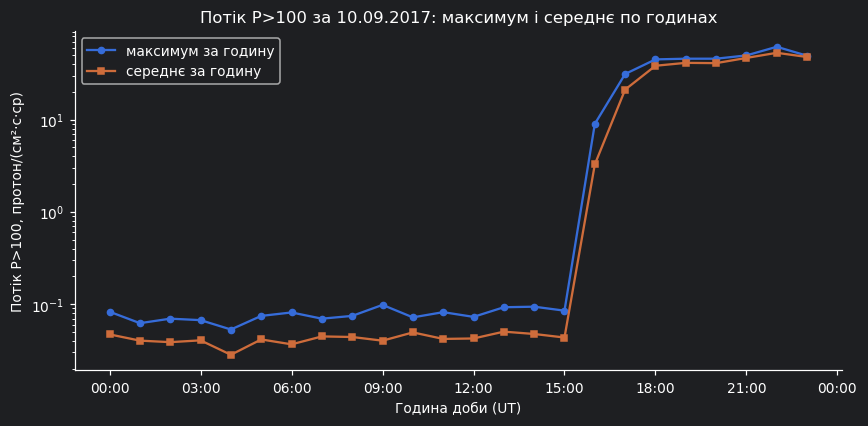

,max,mean
ts,,
2017-09-10 00:00:00,0.0829,0.0471
2017-09-10 01:00:00,0.0623,0.0403
2017-09-10 02:00:00,0.0697,0.0388
2017-09-10 03:00:00,0.0672,0.0406
2017-09-10 04:00:00,0.0532,0.0283
2017-09-10 05:00:00,0.0747,0.0415
2017-09-10 06:00:00,0.0814,0.0367
2017-09-10 07:00:00,0.0697,0.0448
2017-09-10 08:00:00,0.0747,0.0441


In [26]:
# ВАШ КОД
import matplotlib.dates as mdates

FLUX = завдання['ваш потік']                      # потік з індивідуального завдання
AGG = завдання['ваш агрегат для етапу 4']         # агрегат з індивідуального завдання
AGG_FUNCS = {'середнє': 'mean', 'максимум': 'max', 'медіана': 'median', 'мінімум': 'min'}
AGG_NAMES = {v: k for k, v in AGG_FUNCS.items()}
my_agg = AGG_FUNCS[AGG]
other_agg = 'mean' if my_agg != 'mean' else 'max'  # другий агрегат — для порівняння

# Беремо добу, у яку потік досяг найбільшого 5-хвилинного значення
day = A.loc[A[FLUX].idxmax(), 'ts'].normalize()
series = A[A['ts'].dt.normalize() == day].set_index('ts')[FLUX]
hourly = series.resample('h').agg([my_agg, other_agg])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly.index, hourly[my_agg], marker='o', ms=4, label='%s за годину' % AGG_NAMES[my_agg])
ax.plot(hourly.index, hourly[other_agg], marker='s', ms=4, label='%s за годину' % AGG_NAMES[other_agg])
ax.set_yscale('log')                              # у цю добу потік змінюється в рази
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_title('Потік %s за %s: %s і %s по годинах' % (FLUX, day.strftime('%d.%m.%Y'),
                                                    AGG_NAMES[my_agg], AGG_NAMES[other_agg]))
ax.set_xlabel('Година доби (UT)')
ax.set_ylabel('Потік %s, %s' % (FLUX, units(FLUX)))
ax.legend()
plt.show()

display(hourly.round(4))

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Крива максимуму завжди проходить вище, бо вона фіксує найвищий точковий стрибок активності за годину, тоді як середнє просто згладжує всі показники до купи. Ця різниця стає критичною під час раптових і коротких сонячних спалахів, як от на початку різкого зростання між 15:00 та 17:00. Якщо орієнтуватися лише на середнє значення, потужний, але швидкий пік просто "розмиється" на фоні спокійних хвилин, і можна серйозно недооцінити справжню силу викиду.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [27]:
# ВАШ КОД
Ch = C[['ts', 'speed', 'density']]

for how in ['inner', 'outer']:
    print('how=%-6s → %d рядків' % (how, len(Ah.merge(Ch, on='ts', how=how))))

how=inner  → 600 рядків
how=outer  → 601 рядків


In [28]:
print(Ah['ts'].max())
print(Ch['ts'].max())

2017-09-21 23:00:00
2017-09-22 00:00:00


In [29]:
M = Ah.merge(Ch, on='ts', how='outer')

M['day'] = M['ts'].dt.normalize()
M = M.merge(B[['ts', 'F10.7']].rename(columns={'ts': 'day'}), on='day', how='left')
M = M.drop(columns='day').sort_values('ts').reset_index(drop=True)

print('розмір M:', M.shape)
print('\nрядки з хоча б одним пропуском:')
display(M[M.isna().any(axis=1)])

розмір M: (601, 20)

рядки з хоча б одним пропуском:


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,speed,density,F10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0
600,2017-09-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,381.0,1.0,NaN


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

Обрано outer: inner дає 600 рядків, outer - 601. У C є одна зайва година з даними speed/density, якої немає в A. outer її зберігає, при тому ставлячи NaN у стовпцях потоків, а inner просто відкинув би реальні виміри вітру заради рівності таблиць

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [30]:
# ВАШ КОД
GROUPS = ['тиха', 'активна', 'дуже активна']

# right=False: проміжки [-∞, 10), [10, 1000), [1000, +∞) — рівно як в умовах завдання
M['група'] = pd.cut(M['P>10_max'], bins=[-np.inf, 10, 1000, np.inf], labels=GROUPS, right=False)

print(M['група'].value_counts().reindex(GROUPS).to_string())
print('без групи (немає даних P>10):', M['група'].isna().sum())

група
тиха            411
активна         171
дуже активна     18
без групи (немає даних P>10): 1


**Самоперевірка етапу 4.**

In [31]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

P>100: середнє = 1.659, медіана = 0.03949, середнє / медіана = 42.0


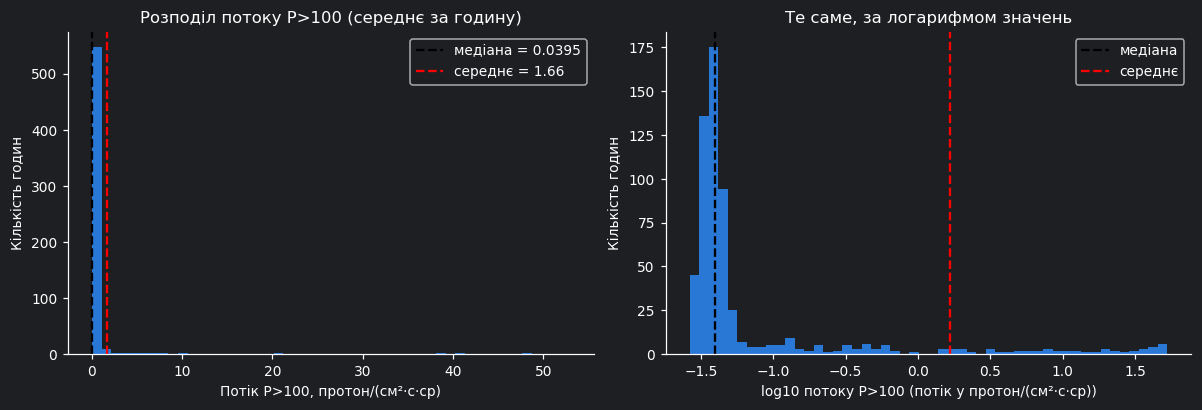

In [32]:
# ВАШ КОД
values = M['%s_mean' % FLUX].dropna()
mean_val, median_val = values.mean(), values.median()
print('%s: середнє = %.4g, медіана = %.4g, середнє / медіана = %.1f' % (FLUX, mean_val, median_val, mean_val / median_val))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

# Ліворуч — «як є»
ax[0].hist(values, bins=50, color='#2a78d6')
ax[0].axvline(median_val, color='k', ls='--', label='медіана = %.3g' % median_val)
ax[0].axvline(mean_val, color='r', ls='--', label='середнє = %.3g' % mean_val)
ax[0].set_title('Розподіл потоку %s (середнє за годину)' % FLUX)
ax[0].set_xlabel('Потік %s, %s' % (FLUX, units(FLUX)))
ax[0].set_ylabel('Кількість годин')
ax[0].legend()

# Праворуч — та сама гістограма від log10 значень
ax[1].hist(np.log10(values), bins=50, color='#2a78d6')
ax[1].axvline(np.log10(median_val), color='k', ls='--', label='медіана')
ax[1].axvline(np.log10(mean_val), color='r', ls='--', label='середнє')
ax[1].set_title('Те саме, за логарифмом значень')
ax[1].set_xlabel('log10 потоку %s (потік у %s)' % (FLUX, units(FLUX)))
ax[1].set_ylabel('Кількість годин')
ax[1].legend()

fig.tight_layout()
plt.show()

**Висновок:**

Розбіжність між середнім та медіаною зумовлено природою кожної метрики, оскільки медіана є центром всього розподілу, за рахунок того що більшість значень сконцентровані ліворуч, та і розміщена медіана, проте через наявність хоч і рідкісних, але дуже високих значень, середнє змістилося ліворуч

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

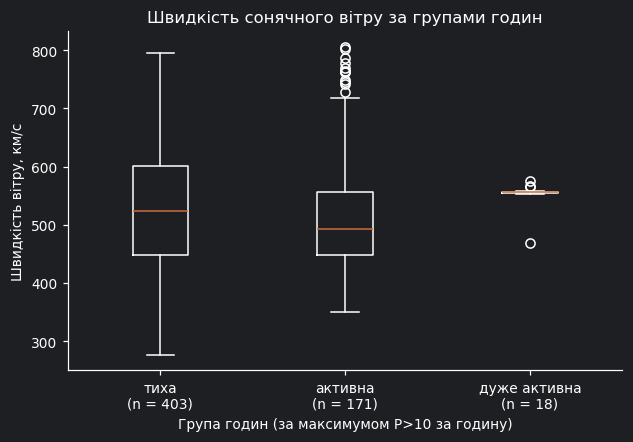

,count,mean,std,min,25%,50%,75%,max
група,,,,,,,,
тиха,403.0,511.3,116.2,277.0,448.5,524.0,600.5,795.0
активна,171.0,515.1,103.4,350.0,447.5,492.0,557.0,806.0
дуже активна,18.0,552.9,21.6,469.0,555.0,556.0,557.0,575.0


In [33]:
# ВАШ КОД
data = [M.loc[M['група'] == g, 'speed'].dropna() for g in GROUPS]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.boxplot(data)
ax.set_xticklabels(['%s\n(n = %d)' % (g, len(d)) for g, d in zip(GROUPS, data)])
ax.set_title('Швидкість сонячного вітру за групами годин')
ax.set_xlabel('Група годин (за максимумом P>10 за годину)')
ax.set_ylabel('Швидкість вітру, км/с')
plt.show()

display(M.groupby('група', observed=True)['speed'].describe().round(1))

**Висновок:**

Найвища швидкість - у дуже активній групі, і в ній розкид найменший, тоді як тиха і активна мають дуже широкий діапазон із безліччю викидів вище у активній. Загалом можна сказати, що зв'язок між потоком енергійних частинок і швидкістю сонячного вітру слабкий: висока швидкість вітру не є надійним провісником чи наслідком спалахів частинок

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

точок: 592 | Пірсон r = 0.059 | Спірмен ρ = -0.081


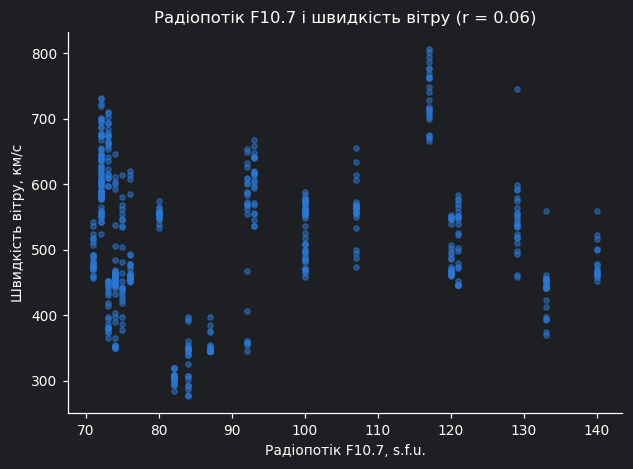

In [34]:
# ВАШ КОД
# Пара з завдання: радіопотік F10.7 та швидкість вітру.
pair = M[['F10.7', 'speed']].dropna()
r_pearson = pair['F10.7'].corr(pair['speed'])
r_spearman = pair['F10.7'].corr(pair['speed'], method='spearman')
print('точок: %d | Пірсон r = %.3f | Спірмен ρ = %.3f' % (len(pair), r_pearson, r_spearman))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(pair['F10.7'], pair['speed'], s=12, alpha=0.5, color='#2a78d6')
ax.set_title('Радіопотік F10.7 і швидкість вітру (r = %.2f)' % r_pearson)
ax.set_xlabel('Радіопотік F10.7, s.f.u.')
ax.set_ylabel('Швидкість вітру, км/с')
plt.show()

**Висновок:**

Залежності немає, обидва коефіцієнти близькі до нуля й навіть різного знаку, а на графіку при кожному значенні F10.7 швидкість розкидана в широкому діапазоні

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

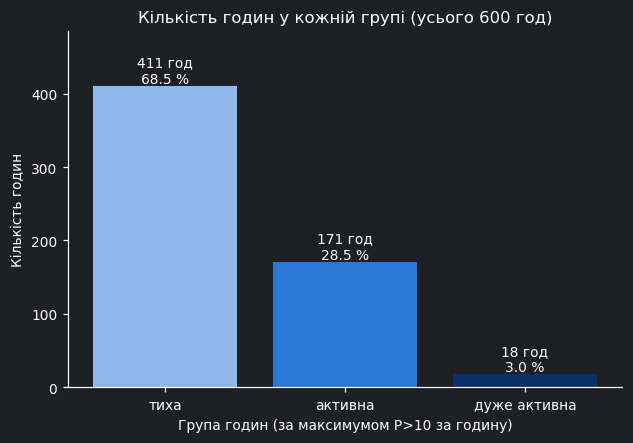

In [35]:
# ВАШ КОД
counts = M['група'].value_counts().reindex(GROUPS)
total = counts.sum()

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(GROUPS, counts.values, color=['#8fb8ea', '#2a78d6', '#0b2f6b'])
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n,
            '%d год\n%.1f %%' % (n, 100 * n / total), ha='center', va='bottom')
ax.set_ylim(0, counts.max() * 1.18)
ax.set_title('Кількість годин у кожній групі (усього %d год)' % total)
ax.set_xlabel('Група годин (за максимумом P>10 за годину)')
ax.set_ylabel('Кількість годин')
plt.show()

**Висновок:**

Більшу частину часу припадає на тиху категорію, найрідкіснішою є, відповіднодуже активна

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

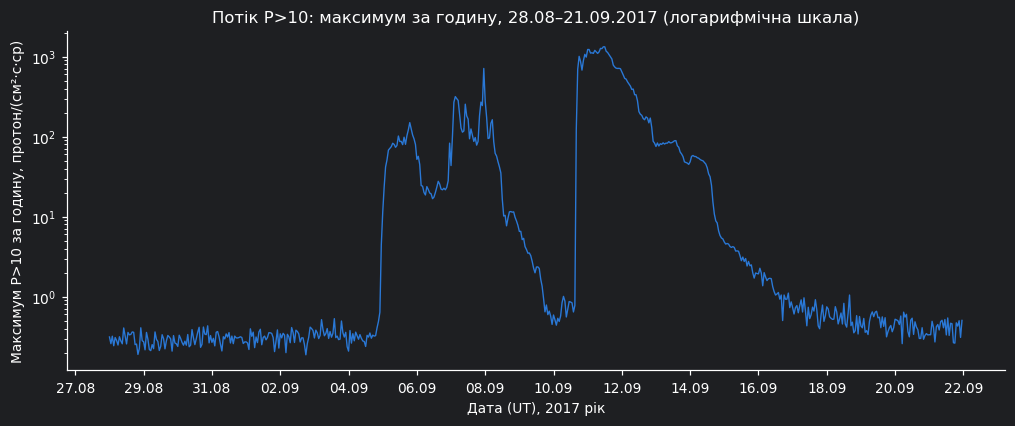

In [36]:
# ВАШ КОД
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(M['ts'], M['P>10_max'], color='#2a78d6', lw=0.9)
ax.set_yscale('log')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.set_title('Потік P>10: максимум за годину, 28.08–21.09.2017 (логарифмічна шкала)')
ax.set_xlabel('Дата (UT), 2017 рік')
ax.set_ylabel('Максимум P>10 за годину, %s' % units('P>10'))
plt.show()

**Висновок:**

До 5 вересня потік тримався стабільно на рівні менше 10. З 5 по ~10 вересня - два епізоди підвищеної активності, із короткочасним провалом між ними. 10–11 вересня - найпотужніший сплеск, потік перевищив поріг 1000, після чого плавно спадав до ~15 вересня. Після 16 вересня рівень знову повернувся до тихого фону, як на початку періоду

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

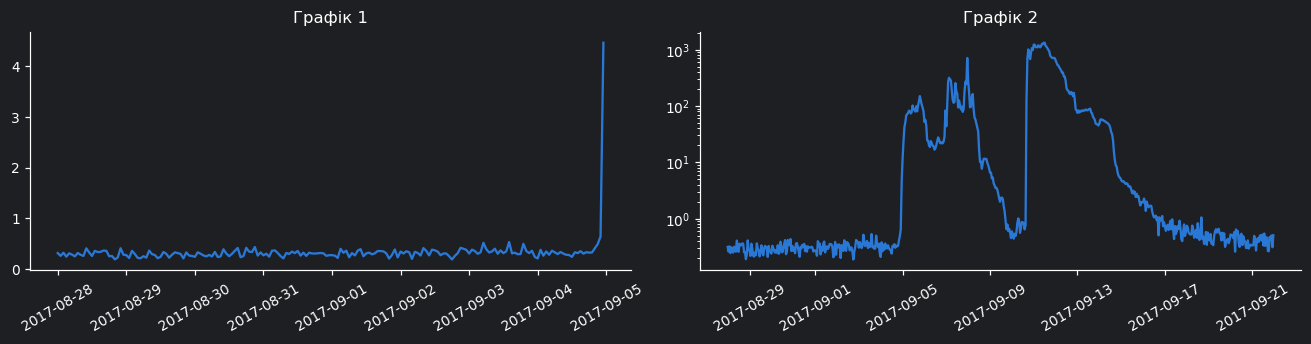

In [37]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: 8 днів активність була досить низькою, проте 5 вересня стався аномальний, дуже великий сплеск
2. Висновок з другого графіка: Графік охоплює діапазон майже в місяць, за цей час спостерігається два періоди підвищення активності, після чого вона повертається до норми
3. Дві відмінності між ними: Перший графік охоплює значно менший часовий проміжок, а драгий, до того ж, вимірюється за логарифмічною шкалою


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

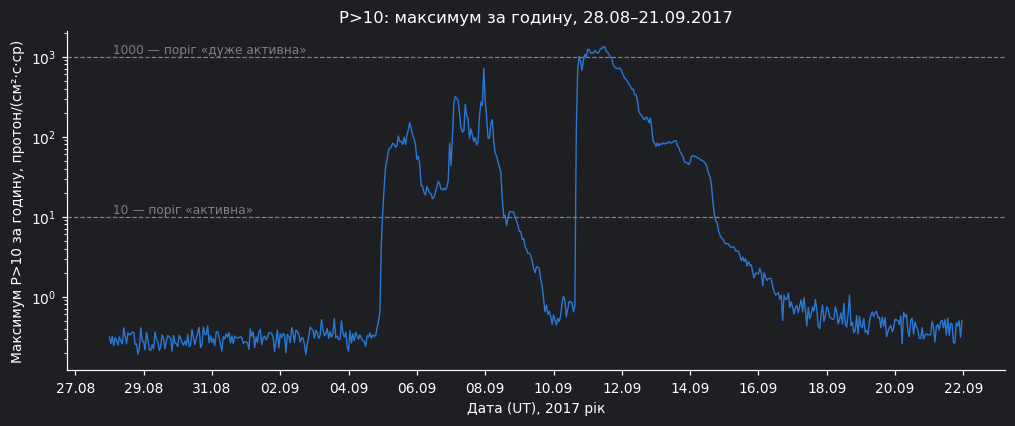

In [38]:
# ВАШ КОД
import matplotlib.dates as mdates

TITLE = 'P>10: максимум за годину, 28.08–21.09.2017'    # ← замініть на заголовок-висновок

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(M['ts'], M['P>10_max'], color='#2a78d6', lw=0.9)
ax.set_yscale('log')
ax.axhline(10, color='gray', ls='--', lw=0.8)
ax.axhline(1000, color='gray', ls='--', lw=0.8)
ax.text(M['ts'].min(), 10, ' 10 — поріг «активна»', va='bottom', fontsize=8, color='gray')
ax.text(M['ts'].min(), 1000, ' 1000 — поріг «дуже активна»', va='bottom', fontsize=8, color='gray')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.set_title(TITLE)
ax.set_xlabel('Дата (UT), 2017 рік')
ax.set_ylabel('Максимум P>10 за годину, %s' % units('P>10'))
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Графік будує потік P>10 (максимум за годину) на логарифмічній шкалі, бо значення змінюються на кілька порядків. На лінійній шкалі, як показано в порівнянні вище, увесь фон стискається в пласку лінію, а видно лише найяскравіший пік; на логарифмічній однаково чітко видно і дрібні коливання тиші, і всі три сплески активності. Показано весь період без обрізання, щоб бачити динаміку цілком, а горизонтальні лінії на рівнях 10 і 1000 позначають межі груп активна і дуже активна, щоб одразу було видно, коли потік перетинає ці пороги

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:**

Середнє потоку P>100 у 42 рази перевищує медіану (1.66 проти 0.0395), бо розподіл дуже скошений - це видно на гістограмі графіка 1, де majority годин мають майже нульове значення, а логарифмічна версія показує двовершинний розподіл

**Спостереження 2:**

Швидкість сонячного вітру майже не залежить від активності частинок P>10 - медіани по групах тиха (524), активна (492) і дуже активна (556 км/с) відрізняються мало, а кореляція з F10.7 практично відсутня (r = 0.059, графік 3)

**Спостереження 3:**

З 600 годин періоду лише 3% (18 год) потрапили в найактивнішу групу, і всі вони припадають лише на дві доби - 10 і 11 вересня (графік 4 і завдання 7.2), тоді як помірна активність (171 год) розтягнута на 9 різних діб

### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [39]:
# ВАШ КОД
# Питання: скільки різних діб потрапило у групу «активна» і скільки — у групу «дуже активна»?
day_of_hour = M['ts'].dt.date

print(M.assign(day=day_of_hour).groupby('група', observed=True)['day'].nunique()
      .reindex(['активна', 'дуже активна']).to_string())

for g in ['активна', 'дуже активна']:
    days = sorted(set(day_of_hour[M['група'] == g]))
    print('\n%s: %d год, %d різних діб' % (g, (M['група'] == g).sum(), len(days)))
    print(', '.join(d.strftime('%d.%m') for d in days))

група
активна         9
дуже активна    2

активна: 171 год, 9 різних діб
05.09, 06.09, 07.09, 08.09, 10.09, 11.09, 12.09, 13.09, 14.09

дуже активна: 18 год, 2 різних діб
10.09, 11.09


**Відповідь 7.2:**

У групи активна та дуже активна потрапили, відповідно, 9 і 2 доби, це також доьре видно з графіка активності зав есь період вище

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [40]:
ІНСТРУМЕНТИ_ШІ = 'Claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = ("Логіку об'єднання таблиць, перевірив, чи справді є нестикування по часу між таблицями A та C. Перевірив чи коректні дані подано в графіки та які шкали використано")

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [41]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Гнатюк Ярослав Богданович
інструменти:                                   Claude
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
Логіку об'єднання таблиць, перевірив, чи справді є нестикування по часу між таблицями A та C. Перевірив чи коректні дані подано в графіки та які шкали використано
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [42]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [43]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
